# Notebook 7 — Multi-task CBM Training

Multi-task end-to-end model:
- MAE-ViT-L encoder (DAPT epoch 3 ckpt, frozen)
- 3D U-Net encoder + decoder (trainable)
- 4 head: detection, concepts, malignancy, segmentation

## Mimari

```
                       Input (1, 64, 64, 64)
                              │
              ┌───────────────┴───────────────┐
              │                               │
              ▼                               ▼
       MAE-ViT-L (frozen)              3D U-Net Encoder
              │                               │
              ▼                          ┌────┴─────┐
         Global pool                     │          │
              │ (B, 1024)             skip      bottleneck
              │                          │          │
              │                          │     Global pool
              │                          │          │ (B, 512)
              └──────────┬─────────────────────────┘
                         │
                  Concat (B, 1536)
                         │
            ┌────────────┼────────────┐
            │            │            │
            ▼            ▼            ▼
      Detection     Concepts     (Seg decoder
      (1536→2)      (1536→8)      U-Net skip
                         │       connection)
                         ▼            │
                    Linear(8→2)       ▼
                         │       Seg logits
                         ▼       (1, 64³)
                    Malignancy
                    (B, 2)
```

## Tasarım

- MAE encoder `requires_grad = False`, çıktı `.detach()`
- 3D U-Net'in encoder kısmı global feature verir, decoder kısmı segmentation üretir
- MAE ve CNN feature'ları concat edilip classification/regression head'lerine girer
- Malignancy = Linear(8 → 2) (concept bottleneck)
- `USE_MAE_FEATURES = False` ile MAE feature'sız varyant denenebilir

## 1. Setup

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os, sys, time, json, gc, shutil, signal
import numpy as np
import pandas as pd
import h5py
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.amp import autocast, GradScaler
from torch.optim.lr_scheduler import LambdaLR
from sklearn.metrics import roc_auc_score, r2_score
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
import requests

print(f'PyTorch: {torch.__version__}')
print(f'CUDA: {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')

Mounted at /content/drive
PyTorch: 2.11.0+cu128
CUDA: True
GPU: NVIDIA A100-SXM4-80GB


In [ ]:
!pip install monai --quiet
from monai.networks.nets import ViT
print('MONAI yüklendi')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 100.4 MB/s eta 0:00:00


<frozen importlib._bootstrap_external>:1301: FutureWarning: The cuda.cudart module is deprecated and will be removed in a future release, please switch to use the cuda.bindings.runtime module instead.


MONAI yüklendi


## 2. Yollar ve config

In [ ]:
DAPT_CKPT = '/content/drive/MyDrive/bitirme/Checkpoints_DAPT/pulmomae_dapt_epoch3_20260525-210449_model_only.pth'
DRIVE_PATCHES_DIR = '/content/drive/MyDrive/bitirme/Finetune_Patches'
LOCAL_PATCHES_DIR = '/content/patches_local'

CHECKPOINTS_DIR = '/content/drive/MyDrive/bitirme/Checkpoints_Hybrid'
LOCAL_CKPT_STAGING = '/content/_hybrid_ckpt_staging'
os.makedirs(CHECKPOINTS_DIR, exist_ok=True)
os.makedirs(LOCAL_CKPT_STAGING, exist_ok=True)

ROI_SIZE = (64, 64, 64)
N_CONCEPTS = 8
USE_MAE_FEATURES = True

# MAE config (frozen)
MAE_PATCH_SIZE = (16, 16, 16)
MAE_HIDDEN_SIZE = 1024
MAE_MLP_DIM = 4096
MAE_NUM_LAYERS = 24
MAE_NUM_HEADS = 16

# Training config
NUM_EPOCHS = 60
BATCH_SIZE = 32
GRAD_ACCUM_STEPS = 1
NUM_WORKERS = 8
LR = 1e-3
WEIGHT_DECAY = 1e-4
WARMUP_FRACTION = 0.1
MAX_GRAD_NORM = 1.0

DET_POS_WEIGHT = 4.0
CONCEPT_NORMALIZE = True

LOSS_WEIGHTS = {
    'detection':    1.0,
    'segmentation': 1.0,
    'malignancy':   1.0,
    'concepts':     0.3,
}

LOG_TRAIN_METRICS = True

CKPT_PREFIX = 'hybrid_v2'
RANDOM_SEED = 42
torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

TELEGRAM_TOKEN  = '8778723398:AAGS-2c5ddGegnc1ErMf1Lz2RZ_xVSwq3c8'
TELEGRAM_CHATID = '7689600055'

print('Config OK')
print(f'  Epochs: {NUM_EPOCHS}, batch {BATCH_SIZE}, LR {LR:.0e}')

Config OK
  Epochs: 60, batch 32, LR 1e-03


## 3. Helpers

In [ ]:
def send_telegram(msg, image_path=None):
    try:
        requests.post(
            f'https://api.telegram.org/bot{TELEGRAM_TOKEN}/sendMessage',
            data={'chat_id': TELEGRAM_CHATID, 'text': msg, 'parse_mode': 'Markdown'},
            timeout=15,
        )
        if image_path and os.path.exists(image_path):
            with open(image_path, 'rb') as f:
                requests.post(
                    f'https://api.telegram.org/bot{TELEGRAM_TOKEN}/sendPhoto',
                    data={'chat_id': TELEGRAM_CHATID},
                    files={'photo': f}, timeout=20,
                )
    except Exception as e:
        print(f'Telegram hata: {e}')

from google.colab import drive as gdrive
def ensure_drive():
    try:
        os.listdir('/content/drive/MyDrive')
        return True
    except OSError:
        try:
            gdrive.mount('/content/drive', force_remount=True)
            time.sleep(3)
            return True
        except Exception:
            return False

print('Helpers OK')

Helpers OK


## 4. H5 Drive → /content

In [ ]:
import shutil
shutil._USE_CP_SENDFILE = False
os.makedirs(LOCAL_PATCHES_DIR, exist_ok=True)

for split in ['train', 'val', 'test']:
    src = os.path.join(DRIVE_PATCHES_DIR, f'patches_{split}.h5')
    dst = os.path.join(LOCAL_PATCHES_DIR, f'patches_{split}.h5')
    if os.path.exists(dst) and os.path.getsize(dst) == os.path.getsize(src):
        print(f'{split}: zaten localde ({os.path.getsize(dst)/(1024*1024):.0f} MB)')
        continue
    t0 = time.time()
    print(f'Copying {split} ({os.path.getsize(src)/(1024*1024):.0f} MB)...')
    chunk_size = 32 * 1024 * 1024
    with open(src, 'rb') as fsrc, open(dst, 'wb') as fdst:
        while True:
            buf = fsrc.read(chunk_size)
            if not buf: break
            fdst.write(buf)
    print(f'  {time.time()-t0:.1f}s')

local_train = os.path.join(LOCAL_PATCHES_DIR, 'patches_train.h5')
local_val   = os.path.join(LOCAL_PATCHES_DIR, 'patches_val.h5')
local_test  = os.path.join(LOCAL_PATCHES_DIR, 'patches_test.h5')
print('\nH5 hazır ✅')

Copying train (1966 MB)...
  21.3s
Copying val (374 MB)...
  4.3s
Copying test (379 MB)...
  7.9s

H5 hazır ✅


## 5. Dataset

In [ ]:
class LUNA16PatchDataset(Dataset):
    def __init__(self, h5_path, training=False, augment=False, hu_clip=(-1000, 1000)):
        self.h5_path = h5_path
        self.training = training
        self.augment = augment and training
        self.hu_clip = hu_clip
        self._h5 = None

        with h5py.File(h5_path, 'r') as h5:
            self.N = h5['patches'].shape[0]
            self.detection_all   = h5['detection'][:]
            self.malignancy_all  = h5['malignancy'][:]
            self.seg_loss_all    = h5['seg_loss_mask'][:]
            self.concepts_all    = h5['concepts'][:]

    def __len__(self):
        return self.N

    def _open_h5(self):
        if self._h5 is None:
            self._h5 = h5py.File(self.h5_path, 'r')
        return self._h5

    def _augment(self, patch, mask):
        for axis in [0, 1, 2]:
            if np.random.rand() < 0.5:
                patch = np.flip(patch, axis=axis)
                mask = np.flip(mask, axis=axis)
        k = np.random.randint(0, 4)
        if k > 0:
            patch = np.rot90(patch, k=k, axes=(1, 2))
            mask = np.rot90(mask, k=k, axes=(1, 2))
        patch = np.ascontiguousarray(patch)
        mask = np.ascontiguousarray(mask)
        if np.random.rand() < 0.3:
            noise = np.random.normal(0, 0.02, patch.shape).astype(np.float32)
            patch = np.clip(patch + noise, 0.0, 1.0)
        return patch, mask

    def __getitem__(self, idx):
        h5 = self._open_h5()
        patch = h5['patches'][idx]
        mask = h5['masks'][idx]

        patch = np.clip(patch.astype(np.float32), self.hu_clip[0], self.hu_clip[1])
        patch = (patch - self.hu_clip[0]) / (self.hu_clip[1] - self.hu_clip[0])
        mask = mask.astype(np.uint8)

        if self.augment:
            patch, mask = self._augment(patch, mask)

        patch_t = torch.from_numpy(patch[np.newaxis, ...])
        mask_t = torch.from_numpy(mask[np.newaxis, ...]).float()

        concepts = self.concepts_all[idx].astype(np.float32).copy()
        if CONCEPT_NORMALIZE and concepts[0] != -1.0:
            concepts = (concepts - 1.0) / 4.0
            concepts = np.clip(concepts, 0.0, 1.5)

        return {
            'patch':         patch_t,
            'mask':          mask_t,
            'detection':     torch.tensor(self.detection_all[idx], dtype=torch.long),
            'malignancy':    torch.tensor(self.malignancy_all[idx], dtype=torch.long),
            'seg_loss_mask': torch.tensor(self.seg_loss_all[idx], dtype=torch.float),
            'concepts':      torch.from_numpy(concepts),
        }

train_ds = LUNA16PatchDataset(local_train, training=True,  augment=True)
val_ds   = LUNA16PatchDataset(local_val,   training=False, augment=False)
test_ds  = LUNA16PatchDataset(local_test,  training=False, augment=False)

print(f'Train: {len(train_ds)}, Val: {len(val_ds)}, Test: {len(test_ds)}')

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                           num_workers=NUM_WORKERS, pin_memory=True,
                           persistent_workers=True, drop_last=True)
val_loader   = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False,
                           num_workers=NUM_WORKERS, pin_memory=True,
                           persistent_workers=True)
test_loader  = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False,
                           num_workers=NUM_WORKERS, pin_memory=True)
print('DataLoaders OK ✅')

Train: 5870, Val: 1100, Test: 1130
DataLoaders OK ✅


## 6. Model

In [ ]:
class ResBlock3D(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.conv1 = nn.Conv3d(in_ch, out_ch, 3, padding=1, bias=False)
        self.norm1 = nn.InstanceNorm3d(out_ch)
        self.conv2 = nn.Conv3d(out_ch, out_ch, 3, padding=1, bias=False)
        self.norm2 = nn.InstanceNorm3d(out_ch)
        self.act = nn.LeakyReLU(0.1, inplace=True)
        self.skip = nn.Conv3d(in_ch, out_ch, 1, bias=False) if in_ch != out_ch else nn.Identity()

    def forward(self, x):
        identity = self.skip(x)
        out = self.act(self.norm1(self.conv1(x)))
        out = self.norm2(self.conv2(out))
        return self.act(out + identity)


class UNet3D(nn.Module):
    def __init__(self, in_channels=1, base=32):
        super().__init__()
        self.stem  = ResBlock3D(in_channels, base)
        self.down1 = nn.Sequential(nn.MaxPool3d(2), ResBlock3D(base, base*2))
        self.down2 = nn.Sequential(nn.MaxPool3d(2), ResBlock3D(base*2, base*4))
        self.down3 = nn.Sequential(nn.MaxPool3d(2), ResBlock3D(base*4, base*8))
        self.bottom = nn.Sequential(nn.MaxPool3d(2), ResBlock3D(base*8, base*16))

        self.global_pool = nn.AdaptiveAvgPool3d(1)

        self.up4 = nn.ConvTranspose3d(base*16, base*8, 2, 2)
        self.dec4 = ResBlock3D(base*16, base*8)
        self.up3 = nn.ConvTranspose3d(base*8, base*4, 2, 2)
        self.dec3 = ResBlock3D(base*8, base*4)
        self.up2 = nn.ConvTranspose3d(base*4, base*2, 2, 2)
        self.dec2 = ResBlock3D(base*4, base*2)
        self.up1 = nn.ConvTranspose3d(base*2, base, 2, 2)
        self.dec1 = ResBlock3D(base*2, base)
        self.final = nn.Conv3d(base, 1, 1)

        self.out_dim = base * 16

    def forward(self, x):
        s0 = self.stem(x)
        s1 = self.down1(s0)
        s2 = self.down2(s1)
        s3 = self.down3(s2)
        b = self.bottom(s3)

        global_feat = self.global_pool(b).flatten(1)

        u4 = self.up4(b)
        d4 = self.dec4(torch.cat([u4, s3], dim=1))
        u3 = self.up3(d4)
        d3 = self.dec3(torch.cat([u3, s2], dim=1))
        u2 = self.up2(d3)
        d2 = self.dec2(torch.cat([u2, s1], dim=1))
        u1 = self.up1(d2)
        d1 = self.dec1(torch.cat([u1, s0], dim=1))
        seg_logits = self.final(d1)

        return global_feat, seg_logits


class HybridMultiTaskCBM(nn.Module):
    def __init__(self, mae_encoder=None, n_concepts=8, use_mae=True, head_dropout=0.1):
        super().__init__()
        self.n_concepts = n_concepts
        self.use_mae = use_mae and (mae_encoder is not None)

        self.mae_encoder = mae_encoder
        if self.mae_encoder is not None:
            for p in self.mae_encoder.parameters():
                p.requires_grad = False
            self.mae_encoder.eval()

        self.cnn = UNet3D(in_channels=1, base=32)

        combined_dim = self.cnn.out_dim + (MAE_HIDDEN_SIZE if self.use_mae else 0)

        self.detection_head = nn.Sequential(
            nn.LayerNorm(combined_dim),
            nn.Linear(combined_dim, 256), nn.GELU(), nn.Dropout(head_dropout),
            nn.Linear(256, 2),
        )
        self.concept_head = nn.Sequential(
            nn.LayerNorm(combined_dim),
            nn.Linear(combined_dim, 256), nn.GELU(), nn.Dropout(0.3),
            nn.Linear(256, n_concepts),
        )
        self.malignancy_head = nn.Linear(n_concepts, 2)

    def forward(self, x):
        cnn_global, seg_logits = self.cnn(x)

        if self.use_mae:
            with torch.no_grad():
                mae_tokens, _ = self.mae_encoder(x)
                mae_global = mae_tokens.mean(dim=1)
            combined = torch.cat([mae_global, cnn_global], dim=1)
        else:
            combined = cnn_global

        det = self.detection_head(combined)
        concepts = self.concept_head(combined)
        mal = self.malignancy_head(concepts)

        return {
            'detection':    det,
            'concepts':     concepts,
            'malignancy':   mal,
            'segmentation': seg_logits,
        }

print('Model class\'ları tanımlandı ✅')

Model class'ları tanımlandı ✅


## 7. Model oluştur

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

if USE_MAE_FEATURES:
    print('MAE encoder yükleniyor...')
    mae_encoder = ViT(
        in_channels=1, img_size=ROI_SIZE, patch_size=MAE_PATCH_SIZE,
        hidden_size=MAE_HIDDEN_SIZE, mlp_dim=MAE_MLP_DIM,
        num_layers=MAE_NUM_LAYERS, num_heads=MAE_NUM_HEADS,
        classification=False,
    )
    ckpt = torch.load(DAPT_CKPT, map_location='cpu', weights_only=False)
    if isinstance(ckpt, dict) and 'model_state_dict' in ckpt:
        encoder_state = ckpt['model_state_dict']
    else:
        encoder_state = ckpt
    missing, unexpected = mae_encoder.load_state_dict(encoder_state, strict=False)
    print(f'  Yüklendi (eksik {len(missing)}, beklenmedik {len(unexpected)})')
    del ckpt, encoder_state
    gc.collect()
else:
    mae_encoder = None

model = HybridMultiTaskCBM(
    mae_encoder=mae_encoder,
    n_concepts=N_CONCEPTS,
    use_mae=USE_MAE_FEATURES,
).to(device)

n_total = sum(p.numel() for p in model.parameters())
n_trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'\nToplam:    {n_total/1e6:.1f}M')
print(f'Trainable: {n_trainable/1e6:.1f}M')

MAE encoder yükleniyor...
  Yüklendi (eksik 0, beklenmedik 0)

Toplam:    431.0M
Trainable: 23.7M


## 8. Forward smoke test

In [ ]:
model.eval()
x = torch.randn(2, 1, *ROI_SIZE, device=device)
with torch.no_grad():
    with autocast('cuda', dtype=torch.bfloat16):
        out = model(x)

expected = {
    'detection': (2, 2), 'concepts': (2, 8),
    'malignancy': (2, 2), 'segmentation': (2, 1, 64, 64, 64),
}
for k, v in out.items():
    ok = '✅' if tuple(v.shape) == expected[k] else '❌'
    print(f'  {ok} {k:14s}: {tuple(v.shape)}')

del x, out
torch.cuda.empty_cache()

  ✅ detection     : (2, 2)
  ✅ concepts      : (2, 8)
  ✅ malignancy    : (2, 2)
  ✅ segmentation  : (2, 1, 64, 64, 64)


## 9. Loss

In [ ]:
def multitask_loss(outputs, batch, weights, eps=1e-7):
    losses = {}

    det_logits = outputs['detection']
    det_target = batch['detection']
    det_class_weight = torch.tensor([1.0, DET_POS_WEIGHT], device=det_logits.device)
    losses['detection'] = F.cross_entropy(det_logits, det_target, weight=det_class_weight)

    mal_logits = outputs['malignancy']
    mal_target = batch['malignancy']
    if (mal_target != -1).any():
        losses['malignancy'] = F.cross_entropy(mal_logits, mal_target, ignore_index=-1)
    else:
        losses['malignancy'] = torch.tensor(0.0, device=mal_logits.device)

    seg_logits = outputs['segmentation']
    seg_target = batch['mask'].float()
    seg_mask = batch['seg_loss_mask'].view(-1, 1, 1, 1, 1).float()

    bce_per_voxel = F.binary_cross_entropy_with_logits(seg_logits, seg_target, reduction='none')
    bce = (bce_per_voxel * seg_mask).sum() / (seg_mask.sum() * 64*64*64 + eps)

    seg_probs = torch.sigmoid(seg_logits)
    dims = (2, 3, 4)
    inter = (seg_probs * seg_target).sum(dim=dims).sum(dim=1)
    union = seg_probs.sum(dim=dims).sum(dim=1) + seg_target.sum(dim=dims).sum(dim=1)
    dice_per_sample = 1.0 - (2.0 * inter + 1.0) / (union + 1.0)
    smps = seg_mask.view(-1)
    if smps.sum() > 0:
        dice_loss = (dice_per_sample * smps).sum() / (smps.sum() + eps)
    else:
        dice_loss = torch.tensor(0.0, device=seg_logits.device)
    losses['segmentation'] = bce + dice_loss

    cp = outputs['concepts']
    ct = batch['concepts'].float()
    cm = (ct[:, 0] != -1.0).float().unsqueeze(1)
    mse_per = F.mse_loss(cp, ct, reduction='none')
    if cm.sum() > 0:
        losses['concepts'] = (mse_per * cm).sum() / (cm.sum() * cp.shape[1] + eps)
    else:
        losses['concepts'] = torch.tensor(0.0, device=cp.device)

    losses['total'] = (weights['detection']    * losses['detection']
                     + weights['segmentation'] * losses['segmentation']
                     + weights['malignancy']   * losses['malignancy']
                     + weights['concepts']     * losses['concepts'])
    return losses

print('Loss OK ✅')

Loss OK ✅


## 10. Optimizer + Scheduler

In [ ]:
trainable_params = [p for p in model.parameters() if p.requires_grad]
optimizer = torch.optim.AdamW(trainable_params, lr=LR, weight_decay=WEIGHT_DECAY)
print(f'Optimizer: {sum(p.numel() for p in trainable_params)/1e6:.1f}M trainable')

total_steps = NUM_EPOCHS * (len(train_loader) // GRAD_ACCUM_STEPS)
warmup_steps = max(1, int(total_steps * WARMUP_FRACTION))
print(f'Total steps: {total_steps}, warmup: {warmup_steps}')

def lr_lambda(step):
    if step < warmup_steps:
        return (step + 1) / warmup_steps
    progress = (step - warmup_steps) / max(1, total_steps - warmup_steps)
    return 0.5 * (1.0 + np.cos(np.pi * progress))

scheduler = LambdaLR(optimizer, lr_lambda=lr_lambda)
scaler = GradScaler('cuda')
print('OK ✅')

Optimizer: 23.7M trainable
Total steps: 10980, warmup: 1098
OK ✅


## 11. compute_metrics

In [ ]:
def compute_metrics(model, loader, device, max_batches=None):
    model.eval()
    all_det_logits, all_det_target = [], []
    all_mal_logits, all_mal_target = [], []
    seg_dices = []
    all_concept_pred, all_concept_target = [], []

    losses_acc = {'detection': 0, 'malignancy': 0, 'segmentation': 0, 'concepts': 0, 'total': 0}
    n_batches = 0

    with torch.no_grad():
        pbar = tqdm(loader, desc='  Eval', leave=False)
        for batch_idx, batch in enumerate(pbar):
            if max_batches and batch_idx >= max_batches:
                break
            batch = {k: v.to(device, non_blocking=True) if isinstance(v, torch.Tensor) else v for k, v in batch.items()}

            with autocast('cuda', dtype=torch.bfloat16):
                out = model(batch['patch'])
                losses = multitask_loss(out, batch, LOSS_WEIGHTS)

            for k in losses_acc:
                losses_acc[k] += losses[k].item()
            n_batches += 1

            all_det_logits.append(out['detection'].float().cpu().numpy())
            all_det_target.append(batch['detection'].cpu().numpy())

            mal_valid = batch['malignancy'] != -1
            if mal_valid.any():
                all_mal_logits.append(out['malignancy'][mal_valid].float().cpu().numpy())
                all_mal_target.append(batch['malignancy'][mal_valid].cpu().numpy())

            seg_probs = torch.sigmoid(out['segmentation']).float()
            seg_target = batch['mask']
            seg_mask = batch['seg_loss_mask']
            for i in range(seg_target.shape[0]):
                if seg_mask[i].item() > 0:
                    p = (seg_probs[i] > 0.5).float()
                    t = seg_target[i].float()
                    inter = (p * t).sum().item()
                    union = p.sum().item() + t.sum().item()
                    dice = (2 * inter + 1) / (union + 1)
                    seg_dices.append(dice)

            cp = out['concepts'].float().cpu().numpy()
            ct = batch['concepts'].cpu().numpy()
            valid_c = ct[:, 0] != -1.0
            if valid_c.any():
                all_concept_pred.append(cp[valid_c])
                all_concept_target.append(ct[valid_c])

    metrics = {'losses': {k: v/n_batches for k, v in losses_acc.items()}}

    if all_det_logits:
        det_logits = np.concatenate(all_det_logits, axis=0)
        det_target = np.concatenate(all_det_target, axis=0)
        det_probs = torch.softmax(torch.from_numpy(det_logits), dim=1)[:, 1].numpy()
        try: metrics['det_auc'] = roc_auc_score(det_target, det_probs)
        except: metrics['det_auc'] = float('nan')

    if all_mal_logits:
        mal_logits = np.concatenate(all_mal_logits, axis=0)
        mal_target = np.concatenate(all_mal_target, axis=0)
        mal_probs = torch.softmax(torch.from_numpy(mal_logits), dim=1)[:, 1].numpy()
        try: metrics['mal_auc'] = roc_auc_score(mal_target, mal_probs)
        except: metrics['mal_auc'] = float('nan')
    else:
        metrics['mal_auc'] = float('nan')

    metrics['seg_dice'] = float(np.mean(seg_dices)) if seg_dices else float('nan')

    if all_concept_pred:
        cp = np.concatenate(all_concept_pred, axis=0)
        ct = np.concatenate(all_concept_target, axis=0)
        try: metrics['concept_r2'] = r2_score(ct, cp, multioutput='uniform_average')
        except: metrics['concept_r2'] = float('nan')
    else:
        metrics['concept_r2'] = float('nan')

    return metrics

print('compute_metrics OK ✅')

compute_metrics OK ✅


## 12. Checkpoint manager

In [ ]:
def save_checkpoint(epoch, model, optimizer, scheduler, scaler, metrics, tag):
    timestamp = time.strftime('%Y%m%d-%H%M%S')
    fname_full = f'{CKPT_PREFIX}_epoch{epoch}_{tag}_{timestamp}_full.pth'
    fname_only = f'{CKPT_PREFIX}_epoch{epoch}_{tag}_{timestamp}_model.pth'
    local_full = os.path.join(LOCAL_CKPT_STAGING, fname_full)
    local_only = os.path.join(LOCAL_CKPT_STAGING, fname_only)

    state = {
        'epoch': epoch, 'tag': tag,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'scheduler_state_dict': scheduler.state_dict(),
        'scaler_state_dict': scaler.state_dict(),
        'metrics': metrics,
    }
    torch.save(state, local_full)
    torch.save(state['model_state_dict'], local_only)

    for local, name in [(local_full, fname_full), (local_only, fname_only)]:
        try:
            shutil.copy(local, os.path.join(CHECKPOINTS_DIR, name))
            os.remove(local)
        except Exception as e:
            print(f'  ⚠️ {name}: {e}')
    return fname_full


def cleanup_old_checkpoints(keep_last=2):
    files = sorted([f for f in os.listdir(CHECKPOINTS_DIR)
                     if f.startswith(CKPT_PREFIX) and 'best' not in f and f.endswith('_full.pth')])
    if len(files) > keep_last:
        for old in files[:-keep_last]:
            for suffix in ['_full.pth', '_model.pth']:
                base = old.replace('_full.pth', suffix)
                path = os.path.join(CHECKPOINTS_DIR, base)
                if os.path.exists(path):
                    try: os.remove(path)
                    except: pass

print('Checkpoint manager OK ✅')

Checkpoint manager OK ✅


## 13. train_one_epoch

In [ ]:
def train_one_epoch(model, loader, optimizer, scheduler, scaler, weights, device, epoch, accum_steps):
    model.train()
    if model.mae_encoder is not None:
        model.mae_encoder.eval()

    losses_acc = {'detection': 0, 'malignancy': 0, 'segmentation': 0, 'concepts': 0, 'total': 0}
    n_batches = 0
    optimizer.zero_grad()

    pbar = tqdm(loader, desc=f'  Epoch {epoch} train', leave=False)
    for batch_idx, batch in enumerate(pbar):
        batch = {k: v.to(device, non_blocking=True) if isinstance(v, torch.Tensor) else v for k, v in batch.items()}

        with autocast('cuda', dtype=torch.bfloat16):
            out = model(batch['patch'])
            losses = multitask_loss(out, batch, weights)
            loss_norm = losses['total'] / accum_steps

        scaler.scale(loss_norm).backward()

        if (batch_idx + 1) % accum_steps == 0:
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), MAX_GRAD_NORM)
            scaler.step(optimizer)
            scaler.update()
            scheduler.step()
            optimizer.zero_grad()

        for k in losses_acc:
            losses_acc[k] += losses[k].item()
        n_batches += 1

        if batch_idx % 10 == 0:
            cur_lr = optimizer.param_groups[-1]['lr']
            pbar.set_postfix(loss=f'{losses["total"].item():.3f}', lr=f'{cur_lr:.1e}')

    if n_batches % accum_steps != 0:
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), MAX_GRAD_NORM)
        scaler.step(optimizer)
        scaler.update()
        scheduler.step()
        optimizer.zero_grad()

    return {k: v/n_batches for k, v in losses_acc.items()}

print('OK ✅')

OK ✅


## 14. Resume

In [ ]:
def find_latest_checkpoint():
    files = sorted([f for f in os.listdir(CHECKPOINTS_DIR)
                     if f.startswith(CKPT_PREFIX) and f.endswith('_full.pth')])
    return os.path.join(CHECKPOINTS_DIR, files[-1]) if files else None

def maybe_resume(model, optimizer, scheduler, scaler):
    latest = find_latest_checkpoint()
    if latest is None:
        print('ℹ️ Fresh start')
        return 0, float('-inf')

    print(f'📥 Resume: {os.path.basename(latest)}')
    ckpt = torch.load(latest, map_location=device, weights_only=False)
    model.load_state_dict(ckpt['model_state_dict'])
    optimizer.load_state_dict(ckpt['optimizer_state_dict'])
    scheduler.load_state_dict(ckpt['scheduler_state_dict'])
    scaler.load_state_dict(ckpt['scaler_state_dict'])

    start_epoch = ckpt['epoch'] + 1
    best_metric = ckpt.get('best_val_mal_auc', float('-inf'))
    print(f'   Epoch {start_epoch}')
    return start_epoch, best_metric

print('OK ✅')

OK ✅


## 15. Ana training loop

In [16]:
start_epoch, best_mal_auc = maybe_resume(model, optimizer, scheduler, scaler)

send_telegram(
    f'🚀 *Training başladı*\n\n'
    f'Epoch: {start_epoch} → {NUM_EPOCHS}\n'
    f'Batch: {BATCH_SIZE}, LR: {LR:.0e}'
)

history = []

try:
    for epoch in range(start_epoch, NUM_EPOCHS):
        epoch_start = time.time()

        train_losses = train_one_epoch(model, train_loader, optimizer, scheduler, scaler,
                                         LOSS_WEIGHTS, device, epoch, GRAD_ACCUM_STEPS)

        val_metrics = compute_metrics(model, val_loader, device)

        train_metrics = None
        if LOG_TRAIN_METRICS:
            train_metrics = compute_metrics(model, train_loader, device, max_batches=30)

        epoch_dt = time.time() - epoch_start

        log_line = (f'\n━━━ EPOCH {epoch+1}/{NUM_EPOCHS} | {epoch_dt/60:.1f} dk ━━━\n'
                    f'Train loss: {train_losses["total"]:.3f} '
                    f'(det={train_losses["detection"]:.2f}, seg={train_losses["segmentation"]:.2f}, '
                    f'mal={train_losses["malignancy"]:.2f}, con={train_losses["concepts"]:.2f})\n')
        if train_metrics:
            log_line += (f'Train: det_AUC={train_metrics["det_auc"]:.4f}, '
                         f'mal_AUC={train_metrics["mal_auc"]:.4f}, '
                         f'Dice={train_metrics["seg_dice"]:.4f}, '
                         f'R²={train_metrics["concept_r2"]:.4f}\n')
        log_line += (f'Val:   det_AUC={val_metrics["det_auc"]:.4f}, '
                     f'mal_AUC={val_metrics["mal_auc"]:.4f}, '
                     f'Dice={val_metrics["seg_dice"]:.4f}, '
                     f'R²={val_metrics["concept_r2"]:.4f}\n')
        print(log_line)

        history.append({
            'epoch': epoch, 'train_losses': train_losses,
            'train_metrics': train_metrics, 'val': val_metrics,
        })

        is_best = val_metrics['mal_auc'] > best_mal_auc and not np.isnan(val_metrics['mal_auc'])
        if is_best:
            best_mal_auc = val_metrics['mal_auc']
            save_checkpoint(epoch, model, optimizer, scheduler, scaler, val_metrics, 'best')
            print(f'   ⭐ Yeni best mal_AUC: {best_mal_auc:.4f}')
        save_checkpoint(epoch, model, optimizer, scheduler, scaler, val_metrics, 'last')
        cleanup_old_checkpoints(keep_last=2)

        msg = (f'📊 *Epoch {epoch+1}/{NUM_EPOCHS}* ({epoch_dt/60:.0f} dk)\n\n'
               f'Val mal\\_AUC: `{val_metrics["mal_auc"]:.4f}`'
               f'{" ⭐" if is_best else ""}\n'
               f'Val det\\_AUC: `{val_metrics["det_auc"]:.4f}`\n'
               f'Val Dice:    `{val_metrics["seg_dice"]:.4f}`\n'
               f'Val R²:      `{val_metrics["concept_r2"]:.4f}`')
        if train_metrics:
            msg += (f'\n\nTrain mal\\_AUC: `{train_metrics["mal_auc"]:.4f}` '
                    f'(gap: `{train_metrics["mal_auc"] - val_metrics["mal_auc"]:+.3f}`)')
        send_telegram(msg)

        gc.collect()
        torch.cuda.empty_cache()

    send_telegram(f'🎉 *Training BİTTİ*\nBest val mal\\_AUC: `{best_mal_auc:.4f}`')

except KeyboardInterrupt:
    print('\n⏸️ Durduruldu')
    send_telegram(f'⏸️ Durduruldu @ epoch {epoch}')
except Exception as e:
    print(f'\n❌ {type(e).__name__}: {e}')
    import traceback; traceback.print_exc()
    send_telegram(f'❌ *Hata*\n`{type(e).__name__}: {str(e)[:200]}`')
    raise

ℹ️ Fresh start


  Epoch 0 train:   0%|          | 0/183 [00:00<?, ?it/s]

  Eval:   0%|          | 0/35 [00:00<?, ?it/s]

  Eval:   0%|          | 0/183 [00:00<?, ?it/s]


━━━ EPOCH 1/60 | 0.9 dk ━━━
Train loss: 2.643 (det=0.69, seg=1.22, mal=0.68, con=0.17)
Train: det_AUC=0.7203, mal_AUC=0.5302, Dice=0.5034, R²=-5.9631
Val:   det_AUC=0.6669, mal_AUC=0.6311, Dice=0.5429, R²=-0.7946

   ⭐ Yeni best mal_AUC: 0.6311


...


━━━ EPOCH 59/60 | 0.9 dk ━━━
Train loss: 0.224 (det=0.01, seg=0.14, mal=0.06, con=0.06)
Train: det_AUC=0.9998, mal_AUC=0.9815, Dice=0.8595, R²=-72.7515
Val:   det_AUC=0.9869, mal_AUC=0.9779, Dice=0.8422, R²=-4.6729



  Epoch 59 train:   0%|          | 0/183 [00:00<?, ?it/s]

  Eval:   0%|          | 0/35 [00:00<?, ?it/s]

  Eval:   0%|          | 0/183 [00:00<?, ?it/s]


━━━ EPOCH 60/60 | 0.9 dk ━━━
Train loss: 0.243 (det=0.01, seg=0.14, mal=0.07, con=0.06)
Train: det_AUC=0.9999, mal_AUC=0.9973, Dice=0.8616, R²=-5.5417
Val:   det_AUC=0.9870, mal_AUC=0.9779, Dice=0.8420, R²=-4.6785



## 16. Test eval

In [17]:
best_files = sorted([f for f in os.listdir(CHECKPOINTS_DIR)
                       if f.startswith(CKPT_PREFIX) and 'best' in f and f.endswith('_full.pth')])

if best_files:
    best_path = os.path.join(CHECKPOINTS_DIR, best_files[-1])
    print(f'Best ckpt: {os.path.basename(best_path)}')
    ckpt = torch.load(best_path, map_location=device, weights_only=False)
    model.load_state_dict(ckpt['model_state_dict'])
    print(f'  Epoch: {ckpt["epoch"]}')

    print('\n=== TEST SET ===')
    test_metrics = compute_metrics(model, test_loader, device)
    print(f'\nTest sonuçları:')
    print(f'  Detection  AUC: {test_metrics["det_auc"]:.4f}')
    print(f'  Malignancy AUC: {test_metrics["mal_auc"]:.4f}')
    print(f'  Segm Dice:      {test_metrics["seg_dice"]:.4f}')
    print(f'  Concept R²:     {test_metrics["concept_r2"]:.4f}')

    send_telegram(
        f'🏁 *FINAL TEST*\n\n'
        f'Det\\_AUC: `{test_metrics["det_auc"]:.4f}`\n'
        f'Mal\\_AUC: `{test_metrics["mal_auc"]:.4f}`\n'
        f'Dice: `{test_metrics["seg_dice"]:.4f}`\n'
        f'R²: `{test_metrics["concept_r2"]:.4f}`'
    )
else:
    print('⚠️ Best ckpt yok')

Best ckpt: hybrid_v2_epoch9_best_20260527-180436_full.pth
  Epoch: 9

=== TEST SET ===


  Eval:   0%|          | 0/36 [00:00<?, ?it/s]


Test sonuçları:
  Detection  AUC: 0.9960
  Malignancy AUC: 0.9681
  Segm Dice:      0.8113
  Concept R²:     -10.0713


## 17. History grafiği

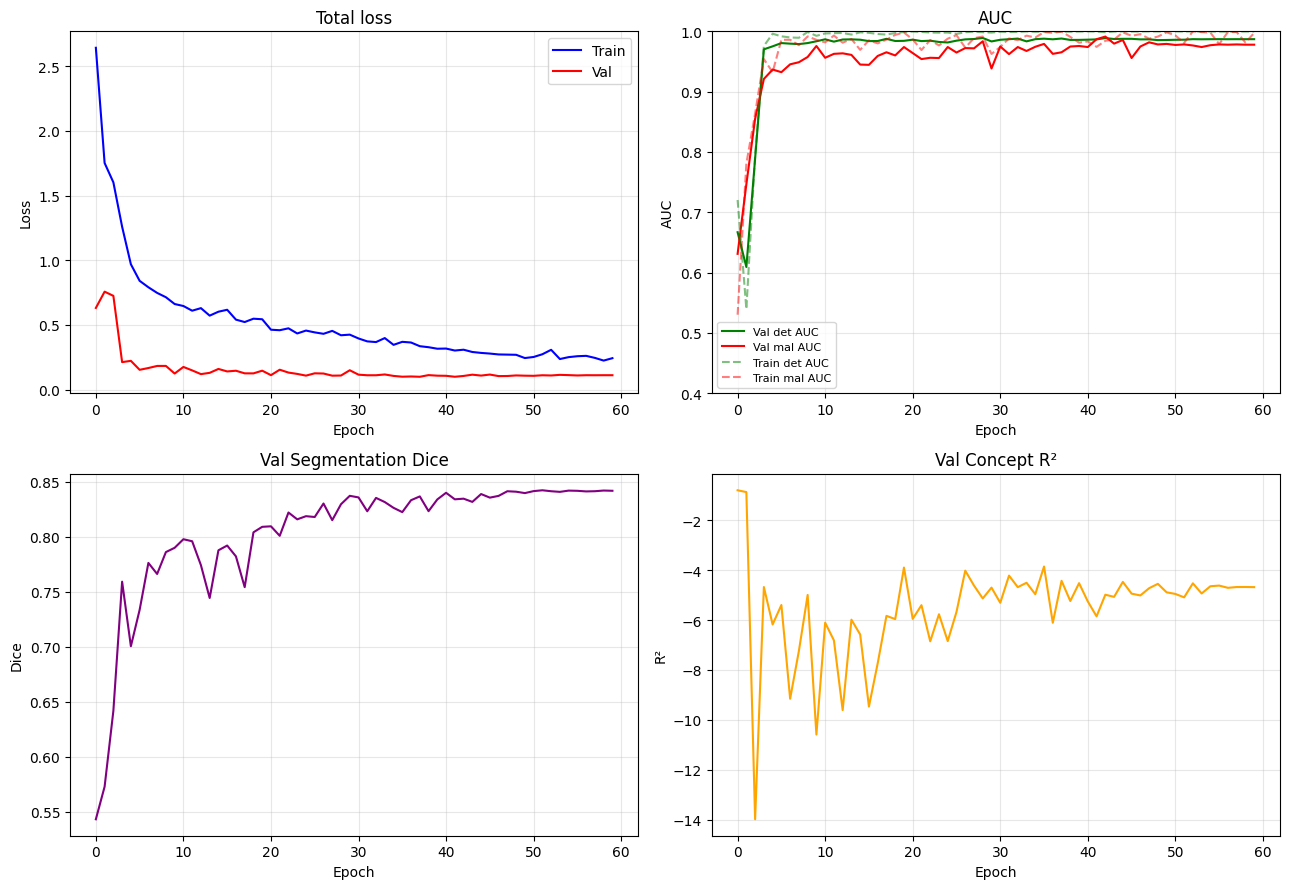

Bitti ✅


In [18]:
if history:
    epochs_arr = [h['epoch'] for h in history]
    train_total = [h['train_losses']['total'] for h in history]
    val_total = [h['val']['losses']['total'] for h in history]
    val_det = [h['val']['det_auc'] for h in history]
    val_mal = [h['val']['mal_auc'] for h in history]
    val_dice = [h['val']['seg_dice'] for h in history]
    val_concept = [h['val']['concept_r2'] for h in history]

    fig, axes = plt.subplots(2, 2, figsize=(13, 9))

    axes[0,0].plot(epochs_arr, train_total, 'b-', label='Train')
    axes[0,0].plot(epochs_arr, val_total, 'r-', label='Val')
    axes[0,0].set_xlabel('Epoch'); axes[0,0].set_ylabel('Loss')
    axes[0,0].set_title('Total loss'); axes[0,0].legend(); axes[0,0].grid(alpha=0.3)

    axes[0,1].plot(epochs_arr, val_det, 'g-', label='Val det AUC')
    axes[0,1].plot(epochs_arr, val_mal, 'r-', label='Val mal AUC')
    train_det = [h['train_metrics']['det_auc'] if h.get('train_metrics') else None for h in history]
    train_mal = [h['train_metrics']['mal_auc'] if h.get('train_metrics') else None for h in history]
    if all(v is not None for v in train_det):
        axes[0,1].plot(epochs_arr, train_det, 'g--', alpha=0.5, label='Train det AUC')
        axes[0,1].plot(epochs_arr, train_mal, 'r--', alpha=0.5, label='Train mal AUC')
    axes[0,1].set_xlabel('Epoch'); axes[0,1].set_ylabel('AUC')
    axes[0,1].set_title('AUC'); axes[0,1].legend(fontsize=8); axes[0,1].grid(alpha=0.3)
    axes[0,1].set_ylim(0.4, 1.0)

    axes[1,0].plot(epochs_arr, val_dice, 'purple')
    axes[1,0].set_xlabel('Epoch'); axes[1,0].set_ylabel('Dice')
    axes[1,0].set_title('Val Segmentation Dice'); axes[1,0].grid(alpha=0.3)

    axes[1,1].plot(epochs_arr, val_concept, 'orange')
    axes[1,1].set_xlabel('Epoch'); axes[1,1].set_ylabel('R²')
    axes[1,1].set_title('Val Concept R²'); axes[1,1].grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig('/content/training_curves_hybrid.png', dpi=100)
    plt.show()

print('Bitti ✅')